In [1]:
"""
Build aligned neural activity dataset across multiple subjects/sessions.

Steps
-----
1) Iterate subjects, read behavioral logs and spike info.
2) For each trial: construct SpikeTrain objects with appropriate windows,
   bin spikes (250 ms), apply sqrt transform, and optionally remove delay
   bins for longer maintenance durations to standardize length.
3) Collect per-session arrays and metadata (conditions, probes, letters, etc.).
4) Build `data` structures expected by `compute_session_alignment`.
5) Align sessions, select well-aligned PCs, visualize alignment diagnostics.
6) Concatenate and save aligned arrays + metadata to ../Data/*.npy.

"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import glob
import compute_session_alignment 

# ---------------------------------------------------------------------
# Containers for all sessions/subjects
# ---------------------------------------------------------------------
bin_size     = 0.250
NPC_TO_ALIGN = 10
completeBinned     = []
completeConditions = []
completeIN         = []
completeSubj       = []
completeProbes     = []
completeLetters    = []
completeUnits      = []
completeSessions   = []
completeReaction   = []
complete_N         = []
completeStart      = []
completeStop       = []
# Subject metadata (IDs + short names)
subNumbers  = ['64','63','61','58','57','54','53','47','45','44','43','40']
subNames    = ['CM','GR','DK','vP','KH','BS','SF','KA','SS','MJ','SP','DG']

# participants with 3s maintenance
#subNumbers  = ['47','45','44','43','40']
#subNames    = ['KA','SS','MJ','SP','DG']

dictResp    = {51:'IN',1:'OUT',52:'OUT',2:'IN',0:'na'}
# ---------------------------------------------------------------------
# Loop over subjects, load behavior + spikes, build binned matrices
# ---------------------------------------------------------------------
for iii in range(len(subNumbers)):
    subNumber = subNumbers[iii]
    subName  = subNames[iii]
      
    letters         = pd.read_csv('../Data/Subject_Data/'+subNumber+'_'+subName+'/monslog.csv',sep=';')
    try:
        letters.columns = ['trials','setSize','letters','past','IN_OUT','probe','correct','1','2','maintDur']
    except:
        letters.columns = ['trials','setSize','letters','past','IN_OUT','probe','correct','1','2']
    letters         = letters[[type(l)==str for l in letters.letters]]
    letters         = letters.reset_index()
    letters['trialAsRecorded']=letters.index+1
    letters.setSize = np.array(letters.setSize,dtype=str)
    letters.past = np.array([p[0] for p in letters.past],dtype=str)
    raster   = []
    all_u    = []
    f = glob.glob('../Data/Subject_Data/'+subNumber+'_'+subName+'/spikeInfo*')
    for fi in f:
        allBinned     = []
        allConditions = []
        allIN         = []
        allSubj       = []
        allProbes     = []
        allLetters    = []
        allUnits      = []
        allSessions   = []
        allReaction   = []
        all_N         = []
        allStart      = []
        allStop       = []
        print(subName,subNumber)
        print(fi)
        trialLoc   = '../Data/Subject_Data/'+subNumber+'_'+subName+'/trialInfo.csv'

        import glob
        spikeLoc = fi
        try:
            df = pd.read_pickle(spikeLoc)
            df.TrialNumber = np.array(df.TrialNumber,dtype=int)
        except:
            print('Error reading file')
            continue
        
        trialInfo = pd.read_csv(trialLoc)
        correctID = np.array(trialInfo[trialInfo.Correct==1].TrialAsRecorded)

        from neo import SpikeTrain
        from elephant.conversion import BinnedSpikeTrain
        import quantities as pq

        tu = np.unique(df.TrialNumber)
        u  = np.unique(df.Unit)
        print(len(tu))
        c  = 0
        cc = 0
        refCount = 0
        for tui in tu:
            
            infoT               = trialInfo[trialInfo.TrialAsRecorded==tui]
            reaction_info       = float(list(infoT.ResponseTime)[0])*1000
            candidate_alignment = letters[np.abs(letters.trialAsRecorded-tui)<200]
            if(np.min(np.abs(candidate_alignment['2']-reaction_info))<1):
                
                info_trial_All      = candidate_alignment[np.abs(candidate_alignment['2']-reaction_info)<1]
                distance            = np.abs(info_trial_All.trialAsRecorded-tui)
                
                #print(int(list(info_trial.setSize)[0]),int(list(infoT.SetSize)[0]), info_trial.IN_OUT,dictResp[list(infoT.Response)[0]])
                good_ones = []
                for index,info_trial in info_trial_All.iterrows():
                    if(int(list(info_trial.setSize)[0])==int(list(infoT.SetSize)[0]) and info_trial.IN_OUT==dictResp[list(infoT.Response)[0]]):
                        good_ones.append(True)
                    else:
                        good_ones.append(False)
                distance       = distance[good_ones]
                info_trial_All = info_trial_All[good_ones]
                info_trial_All = info_trial_All[distance==np.min(distance)]
                
                for index,info_trial in info_trial_All.iterrows():
                    if(int(list(info_trial.setSize)[0])==int(list(infoT.SetSize)[0]) and info_trial.IN_OUT==dictResp[list(infoT.Response)[0]]):
                        if(len(info_trial)>0):
                            if True: #(tui in correctID):
                                c += 1
                                isMain = 'Maint_Dur' in infoT.keys()
                                single_trial  = []
                                single_stream = []
                                for ui in u:
                                    dfu = df[np.logical_and(df.Unit==ui,df.TrialNumber==tui)]
                                    train = dfu.Spiketrain
                                    #print('len train: ',len(train))
                                    if(len(train)==1):
                                        if(not isMain or (isMain and list(infoT.Maint_Dur)[0]==3)):
                                            single_trial.append(SpikeTrain(list(train)[0]*pq.s,t_start=-6*pq.s,t_stop=2*pq.s))
                                            single_stream.append(list(train)[0]+6) #+list(infoT.TimeStampProbe)[0])
                                        elif( isMain and list(infoT.Maint_Dur)[0]==6):
                                            single_trial.append(SpikeTrain(list(train)[0]*pq.s,t_start=-9*pq.s,t_stop=2*pq.s))  
                                            single_stream.append(list(train)[0]+9) #+list(infoT.TimeStampProbe)[0])
                                        elif( isMain and list(infoT.Maint_Dur)[0]==12):
                                            single_trial.append(SpikeTrain(list(train)[0]*pq.s,t_start=-15*pq.s,t_stop=2*pq.s))  
                                            single_stream.append(list(train)[0]+15) #+list(infoT.TimeStampProbe)[0])
                                    else:
                                        print('Error')

                                if(not isMain or  (isMain and list(infoT.Maint_Dur)[0]==3)):
                                    binned   = np.sqrt(BinnedSpikeTrain(single_trial,bin_size=bin_size*pq.s).to_array())
                                    #print(binned.shape)

                                elif( isMain and list(infoT.Maint_Dur)[0]==6):
                                    binned   = np.sqrt(BinnedSpikeTrain(single_trial,bin_size=bin_size*pq.s).to_array())
                                    #binned   = np.concatenate([binned[:,:int(5.5/bin_size)],binned[:,int(8.5/bin_size):]],axis=1)
                                    binned   = np.concatenate([binned[:,:int(6/bin_size)],binned[:,int(9/bin_size):]],axis=1)
                                    #binned   = np.concatenate([binned[:,:int(3/bin_size)],binned[:,int(6/bin_size):]],axis=1)
                                    #print(binned.shape)

                                elif( isMain and list(infoT.Maint_Dur)[0]==12):
                                    binned   = np.sqrt(BinnedSpikeTrain(single_trial,bin_size=bin_size*pq.s).to_array())
                                    #binned   = np.concatenate([binned[:,:int(5.5/bin_size)],binned[:,int(14.5/bin_size):]],axis=1)
                                    binned   = np.concatenate([binned[:,:int(6/bin_size)],binned[:,int(15/bin_size):]],axis=1)
                                    #binned   = np.concatenate([binned[:,:int(3/bin_size)],binned[:,int(12/bin_size):]],axis=1)
                                    #print(binned.shape)

                                if(np.sum(binned)>0 and len(binned)>=NPC_TO_ALIGN):
                                    cc+=1
                                    #if  (tui in correctID):
                                    #m =  np.where(np.array(["H" in ui for ui in u]))[0]
                                    allIN.append(list(infoT.Response)[0])
                                    #allBinned.append(binned[m])
                                    allBinned.append(single_stream)
                                    allConditions.append(1)
                                    allSubj.append(int(subNumber))
                                    allProbes.append(list(info_trial.probe)[0])
                                    allLetters.append(list(info_trial.letters))
                                    allUnits.append(u)
                                    cSes = fi.split('/')[4].split('_')[4].split('.')[0]
                                    if(int(cSes)>=10):
                                        cSes = "&".join(map(str, cSes))
                                    allSessions.append(cSes)
                                    allReaction.append(float(list(infoT.ResponseTime)[0]))
                                    if isMain:
                                        allStart.append(list(infoT.TimeStampProbe)[0]*1e-6 -list(infoT.Maint_Dur)[0]-3)
                                    else:
                                        allStart.append(list(infoT.TimeStampProbe)[0]*1e-6 -3-3)
                                    allStop.append(list(infoT.TimeStampProbe)[0]*1e-6 +2)
                                    if isMain:
                                        #all_N.append([list(infoT.SetSize)[0],tui in correctID, list(infoT.Maint_Dur)[0], list(infoT.Response)[0], float(list(infoT.ResponseTime)[0])])
                                        all_N.append([list(infoT.SetSize)[0],list(infoT.Correct)[0], list(infoT.Maint_Dur)[0], list(infoT.Response)[0], float(list(infoT.ResponseTime)[0])])
                                    else:
                                        #all_N.append([list(infoT.SetSize)[0],tui in correctID, 3, list(infoT.Response)[0], float(list(infoT.ResponseTime)[0])])
                                        all_N.append([list(infoT.SetSize)[0],list(infoT.Correct)[0], 3, list(infoT.Response)[0], float(list(infoT.ResponseTime)[0])])
            #cSes += 1
                    #else:
                    #    print('mismatch')
                    #else:
                    #    print('Error',int(list(info_trial.setSize)[0]),int(list(infoT.SetSize)[0]), info_trial.IN_OUT,dictResp[list(infoT.Response)[0]])
        #print(np.array(allBinned).shape)
        
        print(c,cc)
        if(len(allBinned)):
            completeBinned.append(allBinned)
            completeConditions.append(np.array(allConditions))
            completeIN.append(np.array(allIN))
            completeSubj.append(allSubj)
            completeProbes.append(allProbes)
            completeLetters.append(allLetters)
            completeUnits.append(allUnits)
            completeSessions.append(allSessions)
            completeReaction.append(allReaction)
            complete_N.append(all_N)
            completeStart.append(allStart)
            completeStop.append(allStop)

CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_12.pkl
593
565 96
CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_34.pkl
593
565 94
CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_56.pkl
593
565 90
CM 64
../Data/Subject_Data/64_CM/spikeInfo_64_CM_ses_78.pkl
593
565 0
GR 63
../Data/Subject_Data/63_GR/spikeInfo_63_GR_ses_12.pkl
198
181 93
GR 63
../Data/Subject_Data/63_GR/spikeInfo_63_GR_ses_34.pkl
198
181 88
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_3.pkl
150
144 48
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_2.pkl
150
144 0
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_4.pkl
150
144 47
DK 61
../Data/Subject_Data/61_DK/spikeInfo_61_DK_ses_1.pkl
150
144 49
vP 58
../Data/Subject_Data/58_vP/spikeInfo_58_vP_ses_1.pkl
247
218 41
vP 58
../Data/Subject_Data/58_vP/spikeInfo_58_vP_ses_6.pkl
247
218 0
vP 58
../Data/Subject_Data/58_vP/spikeInfo_58_vP_ses_2.pkl
247
218 43
vP 58
../Data/Subject_Data/58_vP/spikeInfo_58_vP_ses_5.pkl
247
218 44
vP 58
../Data/Sub

In [2]:
np.unique(trialInfo.Response)

array([ 0,  1,  2, 51, 52])

In [3]:
np.unique(letters.IN_OUT)

array(['IN', 'OUT'], dtype=object)

In [4]:
info_trial

index                   449
trials                  450
setSize                   6
letters            XWHCPQGX
past                      n
IN_OUT                   IN
probe                     C
correct               right
1                        na
2                       919
trialAsRecorded         450
Name: 449, dtype: object

In [5]:
infoT

,TrialNumber,Valid,SetSize,Match,Response,Correct,ResponseTime,TimeStampProbe,nTrial_Full,nTrial_Recorded,nTrial_Valid,TimeStartTimestamp,TimeStopTimestamp,Session,TrialAsRecorded
397,50,1,6,1,51,1,0.9195,1.547824e+15,50,400,46,1.547824e+15,1.547824e+15,8,400


In [6]:
completeStream = []
for sessionID in range(len(completeBinned)):
    stream     = []
    for u in range(len(completeBinned[sessionID][0])):
        stream.append(np.concatenate([completeBinned[sessionID][k][u]+(completeStart[sessionID][k]-completeStart[sessionID][0]) for k in range(len(completeBinned[sessionID]))]))
    completeStream.append(stream)

In [7]:
len(completeStream)

35

In [8]:
len(completeStart)

35

In [9]:
len(completeStart[0])

96

In [10]:
len(complete_N[0])

96

In [11]:
complete_N[0][0]

[4, 1, 3, 51, 6.24038696289062]

In [12]:
print(completeSessions[1][0])

3&4


58
5


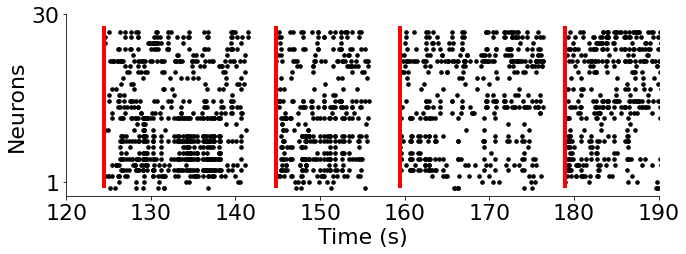

In [19]:
fig,ax = plt.subplots(figsize=(10,4))
plt.rcParams.update({'font.size': 22})

sessionID = 10
ref       = completeStart[sessionID][0]
print(completeSubj[sessionID][0])
print(completeSessions[sessionID][0])
for u in range(len(completeStream[sessionID])):
    plt.scatter(completeStream[sessionID][u],[u]*len(completeStream[sessionID][u]),s=50,marker='.',color='k')
plt.vlines((np.array(completeStart[sessionID])-ref),0,len(completeStream[sessionID]),color='red',alpha=1,linewidth=4)
#plt.vlines((np.array(completeStart[sessionID])-ref+1),0,len(completeStream[sessionID]),color='red',alpha=1,linewidth=4)
#plt.vlines((np.array(completeStart[sessionID])-ref+3),0,len(completeStream[sessionID]),color='red',alpha=1,linewidth=4)
#plt.vlines((np.array(completeStart[sessionID])-ref+6),0,len(completeStream[sessionID]),color='red',alpha=1,linewidth=4)
#plt.vlines((np.array(completeStart[sessionID])-ref+8),0,len(completeStream[sessionID]),color='red',alpha=1,linewidth=4)
plt.xlim(completeStart[sessionID][0]-ref+120,completeStart[sessionID][0]-ref+190)
plt.xlabel('Time (s)')
plt.ylabel('Neurons')
plt.yticks([1,30])
#plt.xticks([672-0.1,673-0.1,675-0.1,678-0.1],[-6,-5,-3,0])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig('pop.png',dpi=200)
plt.show()

In [20]:
np.save('./NWB/probes.npy',np.concatenate(completeProbes))
np.save('./NWB/probes_sep.npy',np.array(completeProbes,dtype=object))
np.save('./NWB/subjs.npy',np.concatenate(completeSubj))
np.save('./NWB/subjs_sep.npy',np.array(completeSubj,dtype=object))
np.save('./NWB/in.npy',np.concatenate(completeIN))
np.save('./NWB/letters.npy',np.concatenate(completeLetters))
np.save('./NWB/letters_sep.npy',np.array(completeLetters,dtype=object))
np.save('./NWB/stream.npy',np.array(completeStream,dtype=object))
np.save('./NWB/spikes.npy',np.array(completeBinned,dtype=object))
np.save('./NWB/reaction.npy',np.array(completeReaction,dtype=object))
np.save('./NWB/units.npy',np.array(completeUnits,dtype=object))
np.save('./NWB/trial_corrInfo.npy',np.array(complete_N,dtype=object))
np.save('./NWB/start.npy',np.array(completeStart,dtype=object))
np.save('./NWB/stop.npy',np.array(completeStop,dtype=object))
np.save('./NWB/session.npy',np.array(completeSessions,dtype=object))

In [21]:
letters

,index,trials,setSize,letters,past,IN_OUT,probe,correct,1,2,trialAsRecorded
0,0,1,4,XXTLQHXX,n,IN,H,right,na,3322,1
1,1,2,4,XXLGRPXX,n,IN,R,right,na,2756,2
2,2,3,6,XHLDTGNX,n,OUT,K,right,na,2010,3
3,3,4,4,XXRQHKXX,n,IN,Q,wrong,na,1238,4
4,4,5,4,XXDCHPXX,n,IN,D,right,na,3416,5
...,...,...,...,...,...,...,...,...,...,...,...
445,445,446,6,XSDVFRQX,n,IN,F,right,na,987,446
446,446,447,8,KFDVCTNW,n,OUT,H,right,na,1561,447
447,447,448,8,HKQFWNLB,n,OUT,R,right,na,1308,448
448,448,449,8,SPNKLBTQ,n,IN,B,right,na,1166,449


In [22]:
trialInfo

,TrialNumber,Valid,SetSize,Match,Response,Correct,ResponseTime,TimeStampProbe,nTrial_Full,nTrial_Recorded,nTrial_Valid,TimeStartTimestamp,TimeStopTimestamp,Session,TrialAsRecorded
0,1,1,4,1,51,1,3.32250,1.547575e+15,1,1,1,1.547575e+15,1.547575e+15,1,1
1,2,1,4,1,51,1,2.75650,1.547575e+15,2,2,2,1.547575e+15,1.547575e+15,1,2
2,3,1,6,2,52,1,2.01000,1.547575e+15,3,3,3,1.547575e+15,1.547575e+15,1,3
3,4,1,4,1,2,0,1.23825,1.547575e+15,4,4,4,1.547575e+15,1.547575e+15,1,4
4,5,1,4,1,51,1,3.41650,1.547575e+15,5,5,5,1.547575e+15,1.547575e+15,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393,46,1,6,1,51,1,0.98775,1.547824e+15,46,396,42,1.547824e+15,1.547824e+15,8,396
394,47,1,8,2,52,1,1.56125,1.547824e+15,47,397,43,1.547824e+15,1.547824e+15,8,397
395,48,1,8,2,52,1,1.30900,1.547824e+15,48,398,44,1.547824e+15,1.547824e+15,8,398
396,49,1,8,1,51,1,1.16625,1.547824e+15,49,399,45,1.547824e+15,1.547824e+15,8,399
